In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.5.0rc2", f"got {md.version('nucleus-cdk')}"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cdk.analysis.cytosol import platereader as pr

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data_file = "data/20251105-labcraft-energy-sweep-01-biotek-cdk.txt"
platemap_file = "data/labcraft-platemap.csv"

data = pr.load_platereader_data(data_file)
data = data[data["Read"] == "GFP-G35"]
data = data.dropna()

In [4]:
data.Well.unique()

array(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'D1', 'D2', 'D3', 'D4',
       'D5', 'D6', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'F1', 'F2', 'F3',
       'F4', 'F5', 'F6', 'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'H1', 'H2',
       'H3', 'H4', 'H5', 'H6', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'J1',
       'J2', 'J3', 'J4', 'J5', 'J6', 'K1', 'K2', 'K3', 'K4', 'K5', 'K6',
       'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'M1', 'M2', 'M3', 'M4', 'M5',
       'M6', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'O1', 'O2', 'O3', 'O4',
       'O5', 'O6', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6'], dtype=object)

In [5]:
data[data.Well == "L5"]

,Time,Well,Data,Row,Column,Read,Plate,Clock Time
5110,0 days 00:00:00,L5,8618.00,L,5,GFP-G35,Plate 1,2025-11-05 11:24:54
5111,0 days 00:05:00,L5,8445.00,L,5,GFP-G35,Plate 1,2025-11-05 11:29:54
5112,0 days 00:10:00,L5,8315.00,L,5,GFP-G35,Plate 1,2025-11-05 11:34:54
5113,0 days 00:15:00,L5,8234.00,L,5,GFP-G35,Plate 1,2025-11-05 11:39:54
5114,0 days 00:20:00,L5,8190.00,L,5,GFP-G35,Plate 1,2025-11-05 11:44:54
...,...,...,...,...,...,...,...,...
5178,0 days 05:40:00,L5,5977.00,L,5,GFP-G35,Plate 1,2025-11-05 17:04:54
5179,0 days 05:45:00,L5,5960.00,L,5,GFP-G35,Plate 1,2025-11-05 17:09:54
5180,0 days 05:50:00,L5,5958.00,L,5,GFP-G35,Plate 1,2025-11-05 17:14:54
5181,0 days 05:55:00,L5,5934.00,L,5,GFP-G35,Plate 1,2025-11-05 17:19:54


In [6]:
platemap = pd.read_csv(platemap_file)

for values, g in platemap.groupby(['Mg Vol (droplets)', 'K Vol (droplets)', 'Water Vol (droplets)']):
    mg, k, water = values
    name = f"Mg {mg}; K {k}"
    platemap.loc[g.index, "Name"] = name

platemap['Type'] = "Sample"

controls = pd.DataFrame(['D5', 'E5', 'F5', 'G5', 'H5', 'I5','J5','K5','L5','M5','N5','O5'], columns=['Well'])
controls['Name'] = [*["1 uM fresh HPTS"]*4, *["10 uM frozen HPTS"]*4, *["10 uM fresh HPTS"]*4]
controls['Type'] = "Standard"


platemap = pd.concat([platemap, controls], ignore_index=True)

In [7]:
platemap.Well.unique()

array(['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'D1', 'D2',
       'D3', 'E1', 'E2', 'E3', 'E4', 'F1', 'F2', 'F3', 'F4', 'G1', 'G2',
       'G3', 'G4', 'H1', 'H2', 'H3', 'H4', 'I1', 'I2', 'I3', 'I4', 'J1',
       'J2', 'J3', 'J4', 'K1', 'K2', 'K3', 'K4', 'L1', 'L2', 'L3', 'L4',
       'M1', 'M2', 'M3', 'M4', 'N1', 'N2', 'N3', 'N4', 'O1', 'O2', 'O3',
       'O4', 'P1', 'P2', 'P3', 'P4', 'D5', 'E5', 'F5', 'G5', 'H5', 'I5',
       'J5', 'K5', 'L5', 'M5', 'N5', 'O5'], dtype=object)

In [8]:
conc = pd.read_csv("data/concentration_key.csv")
conc.columns = ["Well", "[Mg] (mM)", "[K] (mM)", "Water"]
platemap_full = platemap.merge(conc, how="outer")
platemap_full = platemap_full.drop(columns=['K Vol (droplets)', 'Water Vol (droplets)', "Completed", "Water"])
new_columns = {
    "HEPES": 50,
    "ATP": 2,
    "GTP": 2,
    "CTP": 1,
    "UTP": 1,
    "Creatine phosphate": 20,
    "TCEP": 1,
    "Folinic acid": 0.02,
    "Spermidine": 2,
    "Amino Acid solution": 0.3,
    "tRNA": 3.5,
    "DNA":5,
    "Product":"plamGFP",
    "PPK":0,
    
}
platemap_full = platemap_full.assign(**new_columns)

platemap_full.to_csv("full_platemap_cleaned.csv")

In [9]:
platemap.Well.unique()

array(['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'D1', 'D2',
       'D3', 'E1', 'E2', 'E3', 'E4', 'F1', 'F2', 'F3', 'F4', 'G1', 'G2',
       'G3', 'G4', 'H1', 'H2', 'H3', 'H4', 'I1', 'I2', 'I3', 'I4', 'J1',
       'J2', 'J3', 'J4', 'K1', 'K2', 'K3', 'K4', 'L1', 'L2', 'L3', 'L4',
       'M1', 'M2', 'M3', 'M4', 'N1', 'N2', 'N3', 'N4', 'O1', 'O2', 'O3',
       'O4', 'P1', 'P2', 'P3', 'P4', 'D5', 'E5', 'F5', 'G5', 'H5', 'I5',
       'J5', 'K5', 'L5', 'M5', 'N5', 'O5'], dtype=object)

In [10]:
data.Well.unique()

array(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'B1', 'B2', 'B3', 'B4', 'B5',
       'B6', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'D1', 'D2', 'D3', 'D4',
       'D5', 'D6', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'F1', 'F2', 'F3',
       'F4', 'F5', 'F6', 'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'H1', 'H2',
       'H3', 'H4', 'H5', 'H6', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'J1',
       'J2', 'J3', 'J4', 'J5', 'J6', 'K1', 'K2', 'K3', 'K4', 'K5', 'K6',
       'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'M1', 'M2', 'M3', 'M4', 'M5',
       'M6', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'O1', 'O2', 'O3', 'O4',
       'O5', 'O6', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6'], dtype=object)

In [11]:
data = data.merge(platemap)
data = data.merge(conc, how="outer")

In [12]:
data.Well.unique()

array(['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'D1', 'D2',
       'D3', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4',
       'F5', 'G1', 'G2', 'G3', 'G4', 'G5', 'H1', 'H2', 'H3', 'H4', 'H5',
       'I1', 'I2', 'I3', 'I4', 'I5', 'J1', 'J2', 'J3', 'J4', 'J5', 'K1',
       'K2', 'K3', 'K4', 'K5', 'L1', 'L2', 'L3', 'L4', 'L5', 'M1', 'M2',
       'M3', 'M4', 'M5', 'N1', 'N2', 'N3', 'N4', 'N5', 'O1', 'O2', 'O3',
       'O4', 'O5', 'P1', 'P2', 'P3', 'P4'], dtype=object)

# Basic Analysis

## Curves
Curves of RFU over time, by named sample.

In [13]:
data[data.Name == "10 uM fresh HPTS"]

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Experiment,Name,Completed,Mg Vol (droplets),K Vol (droplets),Water Vol (droplets),Type,[Mg] (mM),[K] (mM),Water
3796,0 days 00:00:00,L5,8618.00,L,5,GFP-G35,Plate 1,2025-11-05 11:24:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
3797,0 days 00:05:00,L5,8445.00,L,5,GFP-G35,Plate 1,2025-11-05 11:29:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
3798,0 days 00:10:00,L5,8315.00,L,5,GFP-G35,Plate 1,2025-11-05 11:34:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
3799,0 days 00:15:00,L5,8234.00,L,5,GFP-G35,Plate 1,2025-11-05 11:39:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
3800,0 days 00:20:00,L5,8190.00,L,5,GFP-G35,Plate 1,2025-11-05 11:44:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4959,0 days 05:40:00,O5,4.00,O,5,GFP-G35,Plate 1,2025-11-05 17:04:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
4960,0 days 05:45:00,O5,4.00,O,5,GFP-G35,Plate 1,2025-11-05 17:09:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
4961,0 days 05:50:00,O5,3.00,O,5,GFP-G35,Plate 1,2025-11-05 17:14:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN
4962,0 days 05:55:00,O5,3.00,O,5,GFP-G35,Plate 1,2025-11-05 17:19:54,NaN,10 uM fresh HPTS,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN


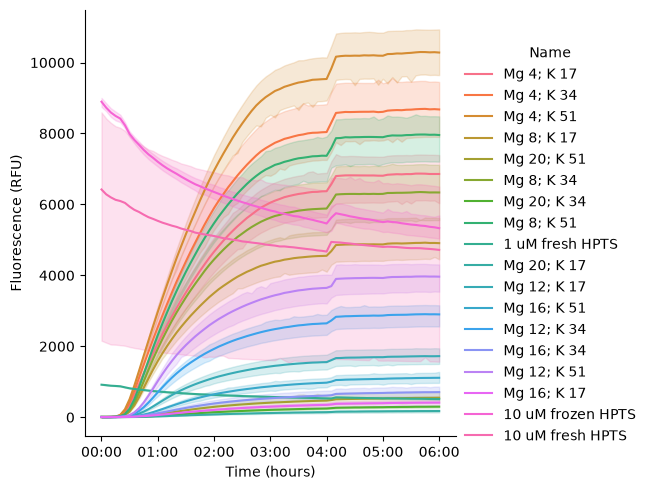

In [14]:
pr.plot_curves(data) #, hue="Well")

In [15]:
data.Name.unique()

array(['Mg 4; K 17', 'Mg 4; K 34', 'Mg 4; K 51', 'Mg 8; K 17',
       'Mg 20; K 51', 'Mg 8; K 34', 'Mg 20; K 34', 'Mg 8; K 51',
       '1 uM fresh HPTS', 'Mg 20; K 17', 'Mg 12; K 17', 'Mg 16; K 51',
       'Mg 12; K 34', 'Mg 16; K 34', 'Mg 12; K 51', 'Mg 16; K 17',
       '10 uM frozen HPTS', '10 uM fresh HPTS'], dtype=object)

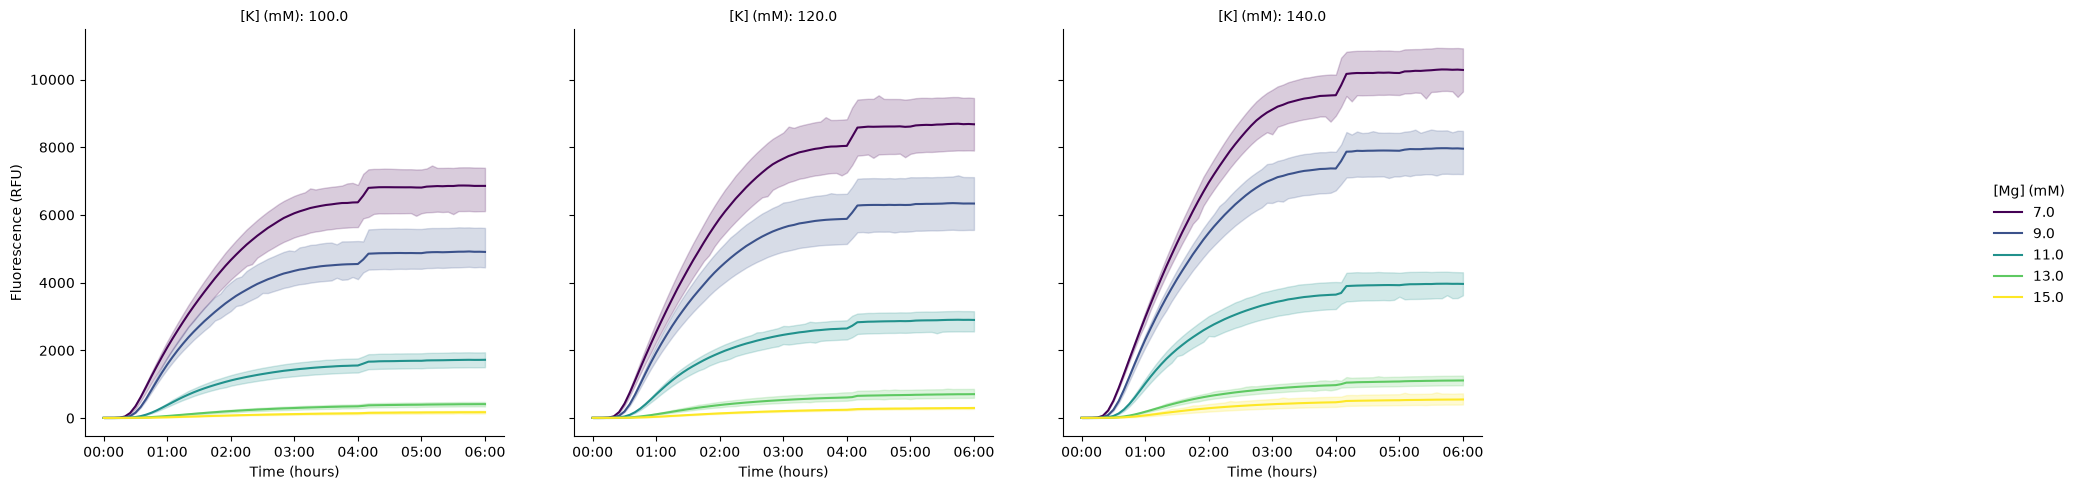

In [16]:
pr.plot_curves(data, hue="[Mg] (mM)", col="[K] (mM)", palette="viridis")

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

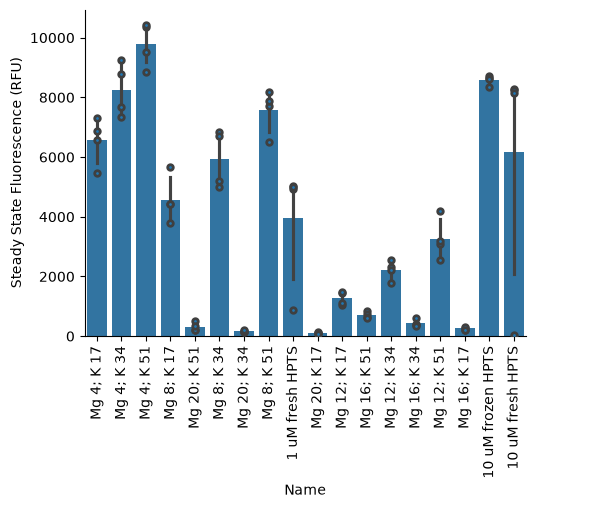

In [17]:
pr.plot_steadystate(data)

In [18]:
kinetics = pr.kinetic_analysis(data, group_by=["Well", "Read", "[Mg] (mM)", "[K] (mM)", "Experiment"])

In [19]:
kinetics.head()

Velocity  \
                                                                                 Time   
Well Read    [Mg] (mM) [K] (mM) Experiment                                              
A1   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 0 days 01:11:42.170502318   
A2   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 0 days 01:13:33.056071363   
A3   GFP-G35 7.00      140.00   Mg_K_screen-20251105_090558 0 days 01:15:35.796198175   
B1   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 0 days 01:12:24.111672656   
B2   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 0 days 01:09:24.867065415   

                                                                             \
                                                               Data     Max   
Well Read    [Mg] (mM) [K] (mM) Experiment                                    
A1   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 3618.76 3061.01   
A2   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 4615.70 3956.73   
A3   GFP-G35 7.00      140.00   Mg_K_screen-20251105_090558 5448.33 4561.27   
B1   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 3859.21 3126.63   
B2   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 3464.14 2867.81   

                                                                                    Lag  \
                                                                                   Time   
Well Read    [Mg] (mM) [K] (mM) Experiment                                                
A1   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558   0 days 00:00:46.205577658   
A2   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558   0 days 00:03:33.502325126   
A3   GFP-G35 7.00      140.00   Mg_K_screen-20251105_090558   0 days 00:03:55.683076752   
B1   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 -1 days +23:58:20.617809842   
B2   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 -1 days +23:56:56.282368679   

                                                                     \
                                                               Data   
Well Read    [Mg] (mM) [K] (mM) Experiment                            
A1   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 -285.38   
A2   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 -289.50   
A3   GFP-G35 7.00      140.00   Mg_K_screen-20251105_090558 -328.89   
B1   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 -426.11   
B2   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 -389.60   

                                                                         Steady State  \
                                                                                 Time   
Well Read    [Mg] (mM) [K] (mM) Experiment                                              
A1   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 0 days 02:56:07.885010914   
A2   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 0 days 02:56:35.720943590   
A3   GFP-G35 7.00      140.00   Mg_K_screen-20251105_090558 0 days 03:01:06.506542689   
B1   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558 0 days 03:01:25.909938372   
B2   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558 0 days 02:56:06.938207440   

                                                                      \
                                                                Data   
Well Read    [Mg] (mM) [K] (mM) Experiment                             
A1   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558  6875.65   
A2   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558  8769.82   
A3   GFP-G35 7.00      140.00   Mg_K_screen-20251105_090558 10351.83   
B1   GFP-G35 7.00      120.00   Mg_K_screen-20251105_090558  7332.51   
B2   GFP-G35 7.00      100.00   Mg_K_screen-20251105_090558  6581.87   

                                                                                                           Fit  \
                             

In [20]:
kinetics.to_csv("Mg_K_screen_20251105_fits.csv")

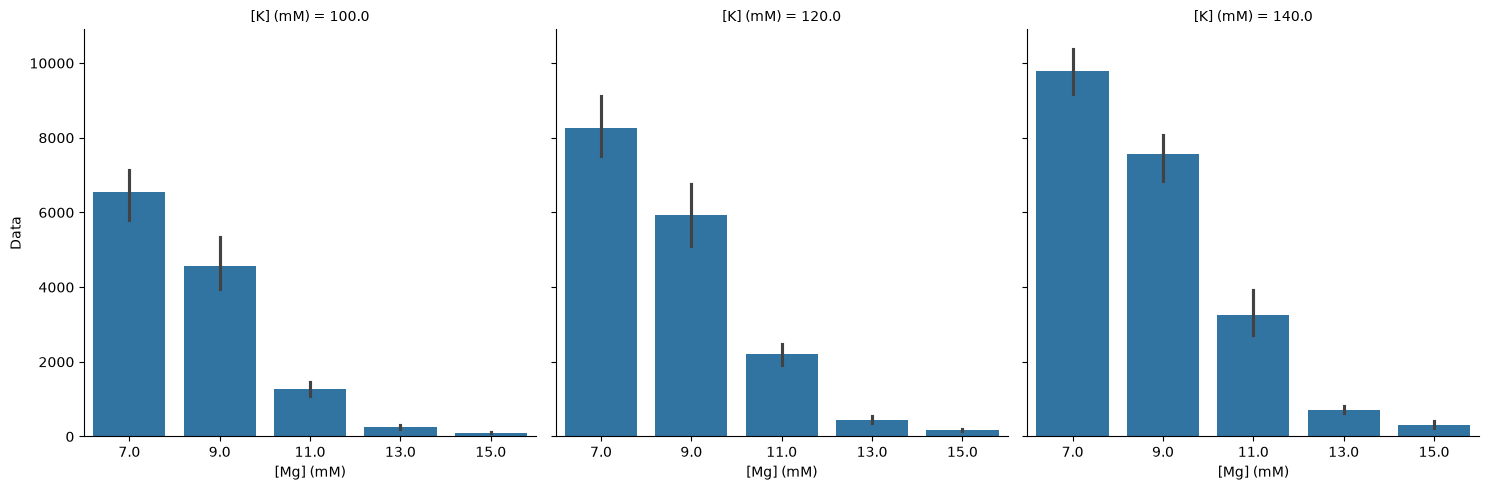

In [21]:
ss = kinetics["Steady State"]["Data"].reset_index().merge(platemap).merge(conc)

sns.catplot(
    data=ss,
    x="[Mg] (mM)",
    y="Data",
    col="[K] (mM)",
    kind="bar"
)

In [22]:
ss.head()

,Well,Read,[Mg] (mM),[K] (mM),Experiment,Data,Name,Completed,Mg Vol (droplets),K Vol (droplets),Water Vol (droplets),Type,Water
0,A1,GFP-G35,7.00,100.00,Mg_K_screen-20251105_090558,6875.65,Mg 4; K 17,True,4.00,17.00,71.00,Sample,0.14
1,A2,GFP-G35,7.00,120.00,Mg_K_screen-20251105_090558,8769.82,Mg 4; K 34,True,4.00,34.00,47.00,Sample,0.09
2,A3,GFP-G35,7.00,140.00,Mg_K_screen-20251105_090558,10351.83,Mg 4; K 51,True,4.00,51.00,23.00,Sample,0.05
3,B1,GFP-G35,7.00,120.00,Mg_K_screen-20251105_090558,7332.51,Mg 4; K 34,True,4.00,34.00,47.00,Sample,0.09
4,B2,GFP-G35,7.00,100.00,Mg_K_screen-20251105_090558,6581.87,Mg 4; K 17,True,4.00,17.00,71.00,Sample,0.14


<Axes: xlabel='[K] (mM)', ylabel='[Mg] (mM)'>

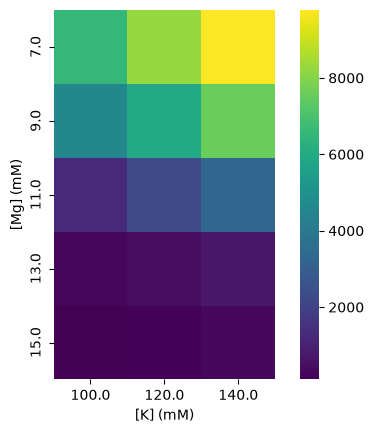

In [23]:
sns.heatmap(
    data=ss.groupby(["[Mg] (mM)", "[K] (mM)"])["Data"].mean().reset_index().pivot(index="[Mg] (mM)", columns="[K] (mM)", values="Data"),
    cmap="viridis",
    square=True
)